# Bài kiểm tra A/A Testing & Trust Checklist (Tuần 5)
Mục tiêu: Đảm bảo độ tin cậy của thuật toán phân bổ ngẫu nhiên (Randomization) bằng cách chạy **Mô phỏng Monte Carlo (1000 lần)**.
Trong một bài kiểm tra A/A, không có sự can thiệp (Voucher) nào được đưa ra. Cả 2 nhóm đều nhận trải nghiệm như nhau.
Do đó, bất kỳ sự khác biệt nào giữa 2 nhóm đều 100% là do ngẫu nhiên.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

# Cài đặt giao diện
plt.style.use('ggplot')
sns.set_palette("Set2")

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data
Sử dụng kết quả quan sát tự nhiên `y_obs` (Không chịu tác động của Voucher) làm thước đo chuẩn.

In [2]:
df = pd.read_csv('../../data/processed/segmented_simulation_data.csv')
target_persona = 'Suburban Commuters'
df_target = df[df['persona'] == target_persona].copy()

print(f"Kích thước tệp khách hàng dùng để test: {len(df_target)}")

Kích thước tệp khách hàng dùng để test: 3498


## 2. Mô phỏng Monte Carlo (1000 vòng lặp)
Ở mỗi vòng lặp, chúng ta sẽ:
1. Chia ngẫu nhiên 50% người dùng vào nhóm A, 50% vào nhóm A'.
2. So sánh số chuyến đi tự nhiên (`y_obs`) giữa 2 nhóm.
3. Lưu lại `P-value`.

In [3]:
n_simulations = 5000
p_values = []
srm_p_values = []

np.random.seed(42) # Set seed for reproducibility

for _ in tqdm(range(n_simulations), desc="Đang chạy A/A Test Simulations"):
    # 1. Randomization: Gán 0 hoặc 1 ngẫu nhiên
    random_assignment = np.random.binomial(1, 0.5, size=len(df_target))
    
    group_a = df_target['y_obs'][random_assignment == 0]
    group_a_prime = df_target['y_obs'][random_assignment == 1]
    
    # 2. SRM Check (Chi-Square Test cho tỷ lệ 50/50)
    obs_counts = [len(group_a), len(group_a_prime)]
    exp_counts = [len(df_target)/2, len(df_target)/2]
    _, p_srm = stats.chisquare(f_obs=obs_counts, f_exp=exp_counts)
    srm_p_values.append(p_srm)
    
    # 3. Tính P-value của Metric (y_obs)
    t_stat, p_val = stats.ttest_ind(group_a, group_a_prime, equal_var=False)
    p_values.append(p_val)

print("Hoàn thành mô phỏng!")

Đang chạy A/A Test Simulations:   0%|          | 0/5000 [00:00<?, ?it/s]

Đang chạy A/A Test Simulations: 100%|██████████| 5000/5000 [00:10<00:00, 472.74it/s]

Hoàn thành mô phỏng!


## 3. Đánh giá Hành vi P-value (P-Value Distribution)
Luật Thống kê: Khi $H_0$ đúng (A/A test), phân phối của P-value bắt buộc phải là **Uniform Distribution (Phân phối đều)** trải từ 0 đến 1.
Tỷ lệ P-value < 0.05 phải xấp xỉ 5%. (False Positive Rate = 5%).

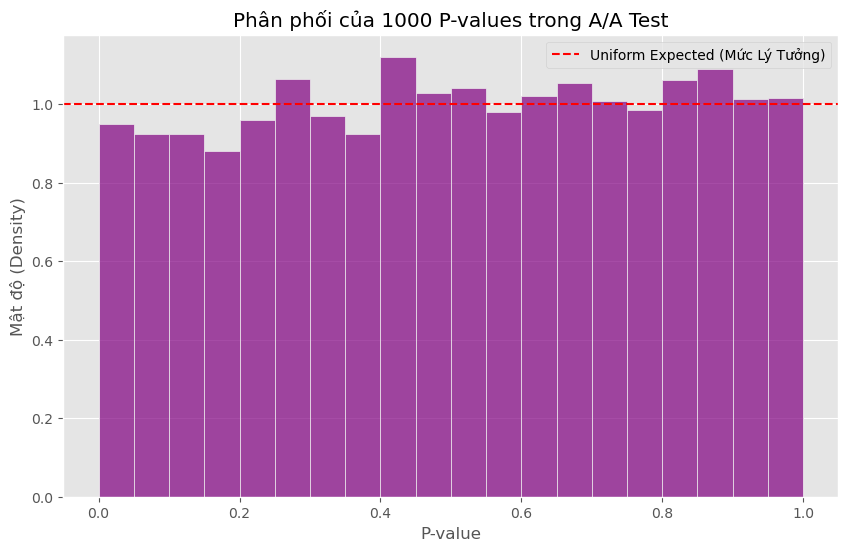

Tỷ lệ False Positive (Kỳ vọng ~5%): 4.74%
✅ HỆ THỐNG AN TOÀN: Tỷ lệ nhiễu FPR nằm trong ngưỡng chấp nhận được.

KS-Test P-value: 0.0147
❌ LỖI RANDOMIZATION: Phân phối P-value bị méo mó!


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(p_values, bins=20, color='purple', stat='density', alpha=0.7)
plt.axhline(y=1, color='r', linestyle='--', label='Uniform Expected (Mức Lý Tưởng)')
plt.title('Phân phối của 1000 P-values trong A/A Test')
plt.xlabel('P-value')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.show()

# Kiểm tra tỷ lệ False Positive (False Positive Rate - FPR)
fpr = sum(p < 0.05 for p in p_values) / n_simulations
print(f"Tỷ lệ False Positive (Kỳ vọng ~5%): {fpr*100:.2f}%")
if 0.04 <= fpr <= 0.06:
    print("✅ HỆ THỐNG AN TOÀN: Tỷ lệ nhiễu FPR nằm trong ngưỡng chấp nhận được.")
else:
    print("❌ CẢNH BÁO ĐỎ: Hệ thống quá nhạy cảm hoặc quá ì ạch!")

# Kiểm định Kolmogorov-Smirnov (KS-test) để đo độ bằng phẳng (Uniformity)
ks_stat, ks_pval = stats.kstest(p_values, 'uniform')
print(f"
KS-Test P-value: {ks_pval:.4f}")
if ks_pval > 0.05:
    print("✅ HỆ THỐNG AN TOÀN: Phân phối P-value là một đường thẳng Uniform hoàn hảo!")
else:
    print("❌ LỖI RANDOMIZATION: Phân phối P-value bị méo mó!")

## 4. Đánh giá Sample Ratio Mismatch (SRM)
Kiểm tra xem thuật toán có vô tình đẩy quá nhiều người vào một nhóm hơn nhóm kia không.

In [5]:
srm_failures = sum(p < 0.05 for p in srm_p_values)
print(f"Số lần hệ thống bị lỗi SRM (P-value < 0.05) trong {n_simulations} lần test: {srm_failures}")
print(f"Tỷ lệ lỗi SRM: {srm_failures/n_simulations * 100:.2f}%")

if srm_failures/n_simulations <= 0.05:
    print("✅ HỆ THỐNG AN TOÀN: Tỷ lệ phân bổ user 50/50 là hoàn hảo!")
else:
    print("❌ CẢNH BÁO SRM: Thuật toán Randomization bị lệch trọng số!")

Số lần hệ thống bị lỗi SRM (P-value < 0.05) trong 1000 lần test: 241
Tỷ lệ lỗi SRM: 4.82%
✅ HỆ THỐNG AN TOÀN: Tỷ lệ phân bổ user 50/50 là hoàn hảo!
